In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch, glob
import matplotlib.pyplot as plt
import numpy as np
from wassa_plots import plot_hp_tuning, plot_SM, plot_results, plot_similarity_matrix
from wassa_utils import get_best_results, compute_factors_distributions, smoothing, sliding_correlation
from wassa_training import get_training_parameters, learn_motifs, unsupervised_learning
from wassa_metrics import get_similarity
from wassa import WassA
from dataset_generation import kfold_dataset, generate_dataset, get_dataset_parameters

## Get statistics from real data

In [3]:
dataset_path = '../allen_data_by_image/'
dataset_name = 'bin_tensor_session_02_NS'
data = torch.load(dataset_path+dataset_name+'.pt', weights_only = True)

FileNotFoundError: [Errno 2] No such file or directory: '../allen_data_by_image/bin_tensor_session_02_NS.pt'

In [4]:
device = 'cuda'

In [6]:
training_set, testing_set = data[:7], data[7:10]

In [5]:
training_parameters = {
    'kernel_size' : (6,training_set.shape[1],training_set.shape[2]),
    'loss_type' : 'emd',
    'N_learnsteps' : 500,
    'learning_rate' : .001,
    'beta_1' : .9,
    'penalty_type' : ['kernels_orthogonality'],
    'smoothwind' : 0,
    'expected_patterns_per_sample' : 0,
    'lambda' : [1e-6],
    'batch_size' : None,
    'do_bias' : [False,True,True],
    'tied_weights' : False,
    'weight_init' : None,
    'normalize_input' : False,
    'reshape_input': False}

NameError: name 'training_set' is not defined

In [8]:
k_fold, n_iter = 3, 5
metric_names = ['training loss', 'testing loss', 'explained variance', 'penalty value', 'kernels correlation', 'train/test factors difference']
results = unsupervised_learning([training_parameters],data[:10],metric_names,dataset_name,k_fold=k_fold,n_iter=n_iter,device=device)

AttributeError: 'tuple' object has no attribute 'copy'

In [8]:
decoding_weights = torch.zeros([n_iter,k_fold,training_parameters['kernel_size'][0],training_parameters['kernel_size'][1],training_parameters['kernel_size'][2]])
encoding_weights = torch.zeros([n_iter,k_fold,training_parameters['kernel_size'][0],training_parameters['kernel_size'][1],training_parameters['kernel_size'][2]])
all_factors = torch.zeros([n_iter,k_fold,data.shape[0],training_parameters['kernel_size'][0],testing_set[0].shape[-1]-training_parameters['kernel_size'][2]+1])
record_path='../results/'
for iteration in range(n_iter):
    for fold in range(k_fold):
        model_name = record_path + dataset_name + str(iteration) + str(fold) + get_training_parameters(training_parameters)
        model = WassA(training_parameters, device=device)
        model.load_state_dict(torch.load(model_name + '.pth', map_location=torch.device(training_set.device),weights_only=True))
        decoding_weights[iteration,fold], encoding_weights[iteration,fold] = model.decoder[0].weight.data, model.encoder[0].weight.data
        #decoding_weights[iteration,fold] = model.weights.data.detach()
        all_factors[iteration,fold], _ = model(data.to(torch.float).to(device))

similarity threshold : 0.775


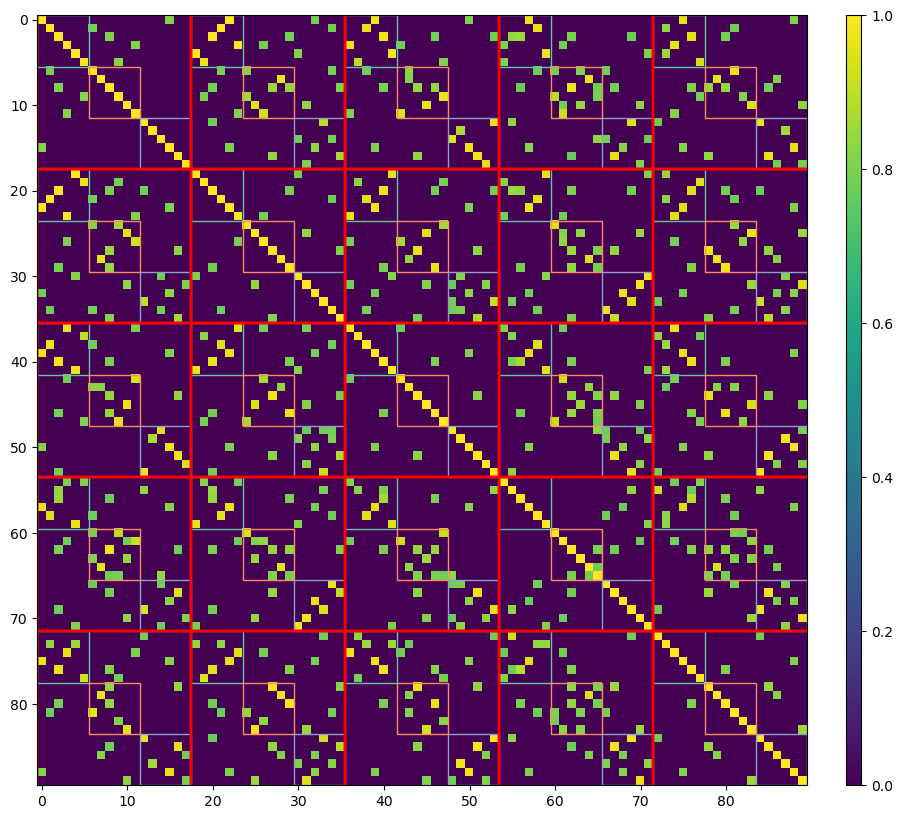

In [50]:
n_iter, n_folds, n_kernels, n_neurons, n_timesteps = encoding_weights.shape
corr_matrix = sliding_correlation(decoding_weights.flatten(end_dim=2))#-torch.eye(n_iter*n_folds*n_kernels)
plot_similarity_matrix(corr_matrix, n_iter, n_folds, n_kernels,quant=.9)

In [47]:
import scipy.spatial.distance as ssd
# convert the redundant n*n square matrix form into a condensed nC2 array
distArray = ssd.squareform(1-corr_matrix) # distArray[{n choose 2}-{n-i choose 2} + (j-i-1)] is the distance between points i and j

In [ ]:
similarity_threshold = .775
thresholded_matrix = torch.zeros_like(corr_matrix)
thresholded_matrix[corr_matrix<similarity_threshold] = 0
for i in range(corr_matrix.shape[0]):
    

In [46]:
value, count = torch.unique(torch.randint(100,[10])//3, return_counts=True)

(tensor([ 3,  6,  9, 11, 14, 18, 22, 24, 28, 29]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [ ]:
def return_iteration_and_fold_specificity(index,number_kernels,number_folds,number_iterations):
    iteration_number = index//(number_kernels*number_folds)
    iteration_value, iteration_count = torch.unique(iteration_number,return_counts=True)
    fold_number = index%(number_kernels*number_folds)//number_kernels
    fold_value, fold_count = torch.unique(fold_number,return_counts=True)
    trial_number = index//number_kernels
    trial_value, trial_count = torch.unique(trial_number,return_counts=True)
    total_count = trial_count.sum()
    trial_frequency = trial_count/total_count
    iteration_frequency = iteration_count/total_count
    fold_frequency = fold_count/total_count
    

In [38]:
70%(6*3)//6

2

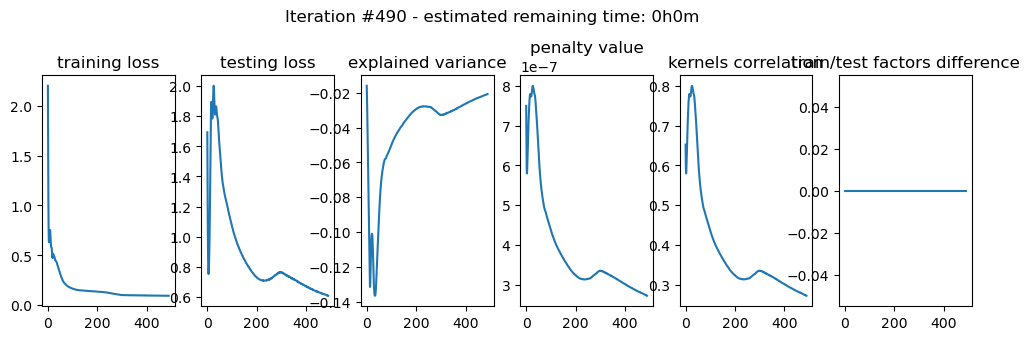

In [68]:
metric_names = ['training loss', 'testing loss', 'explained variance', 'penalty value', 'kernels correlation', 'train/test factors difference']
autoencoder = WassA(training_parameters, device=device)
model, training_metrics, metric_names = learn_motifs(autoencoder,training_set.to(torch.float).to(device),testing_set.to(torch.float).to(device),training_parameters,'testing_static_sparse',metric_names,online_plots=True)

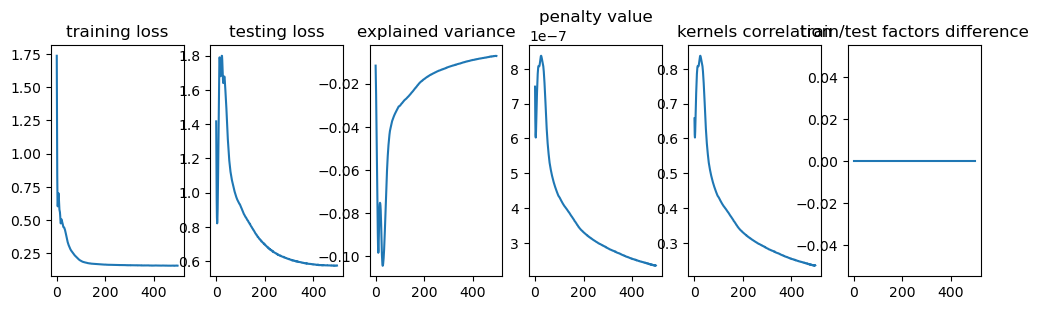

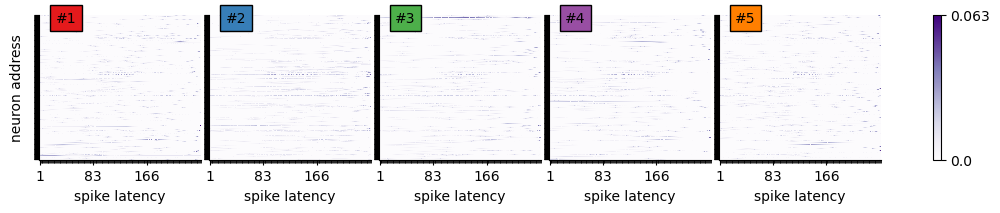

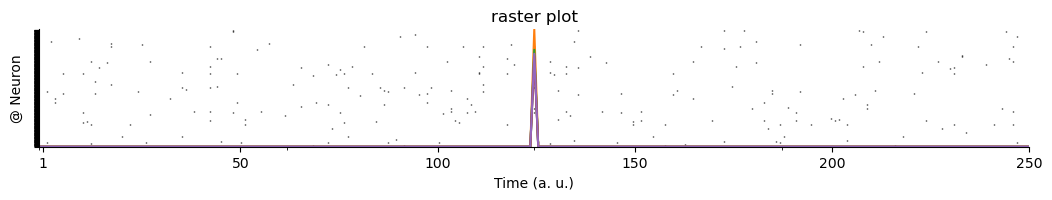

In [61]:
plot_results(training_metrics, metric_names, model, testing_set.to(torch.float).to(device), order_sms=False)

In [4]:
avg_fr = torch.mean(data.to(torch.float),axis=(0,2))*1e3
n_samples, n_neurons, n_timesteps =  data.shape

In [5]:
avg_fr[avg_fr==0] = .1

## Generate synthetic data

In [6]:
device = 'cuda:1'

In [43]:
dataset_parameters = {
    'seed' : 666,
    
    'N_pre' : 150, # number of neurons
    'N_timesteps' : 52, # number of timesteps for the raster plot (in ms)
    'N_samples' : 60, # total number of samples in the dataset

    'N_delays' : 51, # number of timesteps in spiking motifs, must be a odd number for convolutions
    'N_SMs' : 1, # number of structured spiking motifs
    'avg_fr' : 20, # average firing rate of the neurons (in Hz)
    'std_fr' : .1, # standard deviation for the firing rates of the different neurons
    'overlapping_sms' : True, # possibility to have overlapping sequences

    'temporal_jitter' : 2, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic parout_channelsticipations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'warping_coef' : 1, # coefficient for time warping

}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_SMs'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'frs' : torch.normal(dataset_parameters['avg_fr'], dataset_parameters['std_fr'], size=(dataset_parameters['N_pre'],)).abs()})
dataset_parameters.update({'freq_sms' : 100*torch.ones(dataset_parameters['N_SMs'])}) # frequency of apparition of the different spiking motifs (in Hz)
dataset_parameters.update({'coefficient_variation' : 1*torch.ones(dataset_parameters['N_pre'],device=device)}) # coefficient of variation of the FRs of each neuron (within VS. without a motif)

In [44]:
sm, dataset_input, dataset_output = generate_dataset(dataset_parameters, record_path = '../synthetic_data/', device=device)
dataset_name = get_dataset_parameters(dataset_parameters)

../synthetic_data/generative_model_6661505260511200.1True200.11150.0100.01.0


In [45]:
metric_names = ['training loss', 'testing loss', 'explained variance', 'penalty value', 'kernels correlation', 'train/test factors difference']

In [46]:
training_parameters = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_delays']),
    'loss_type' : 'emd',
    'N_learnsteps' : 1000,
    'learning_rate' : .001,
    'beta_1' : .9,
    'penalty_type' : ['bias'],
    'smoothwind' : 0,
    'expected_patterns_per_sample' : dataset_parameters['N_timesteps']*dataset_parameters['freq_sms'][0]*1e-3,
    'lambda' : [0.01],
    'batch_size' : None,
    'do_bias' : [True,False,False],
    'tied_weights' : True,
    'weight_init' : 'flat',
    'normalize_input' : True,
    'reshape_input': False}

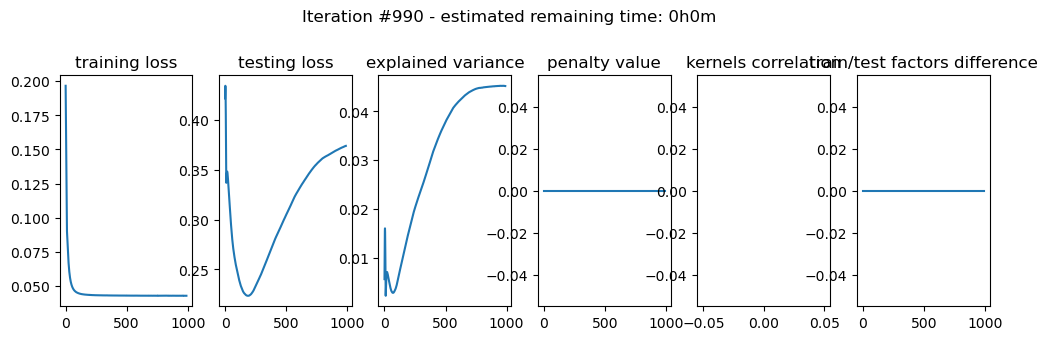

In [47]:
number_iterations, number_folds = 2, 4
trainsets, testsets, indices = kfold_dataset(dataset_input,k=number_folds)
iteration, k = 1, 0
training_set, testing_set = trainsets[k], testsets[k]
saving_path = '../results/'
model = WassA(training_parameters,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+get_training_parameters(training_parameters)
model, training_metrics, metric_names = learn_motifs(model, training_set, testing_set, training_parameters, model_name, metric_names,online_plots=True)

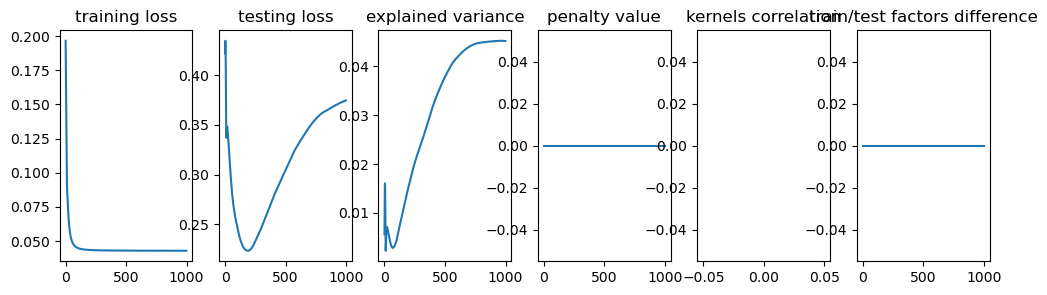

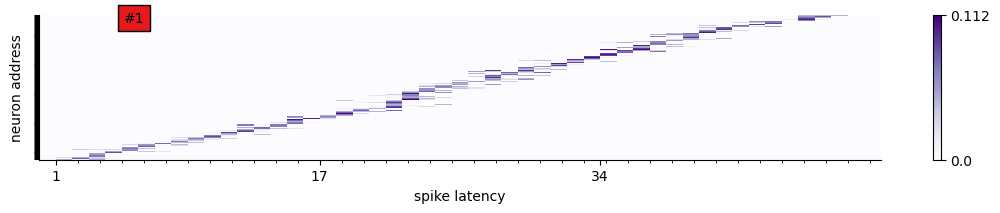

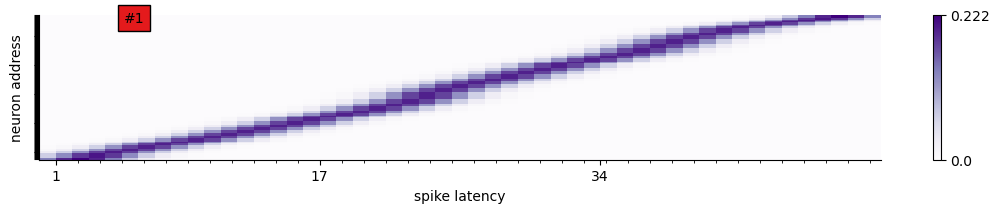

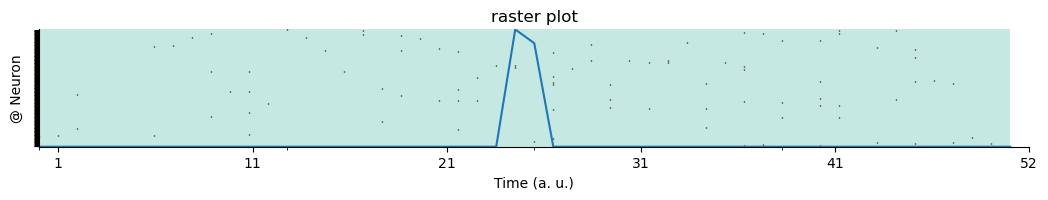

In [48]:
trainsets_output, testsets_output, indices = kfold_dataset(dataset_output,k=number_folds,existing_indices=indices)
plot_results(training_metrics, metric_names, model, testing_set, order_sms=True, true_occurence=testsets_output[k], true_weights=sm.SMs)

In [50]:
synthetic_metrics=['factors similarity', 'kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings']
similarity_results = get_similarity(sm, model, testing_set,metric_names=synthetic_metrics,verbose=True)

factors similarity : 0.236
kernels similarity : 0.605
mean timings similarity : 0.386
mse : 0.002
emd : 1.354
emd mean timings : 0.727


## Check variability for multiple iterations

In [14]:
verb = True
n_iterations = 5
n_folds = 5
results_learning = unsupervised_learning([training_parameters],[sm, dataset_input],metric_names,dataset_name,k_fold=n_folds,n_iter=n_iterations,synthetic_metrics=synthetic_metrics,record_path=saving_path,device=device,verbose=verb)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  0%|          | 0/2000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



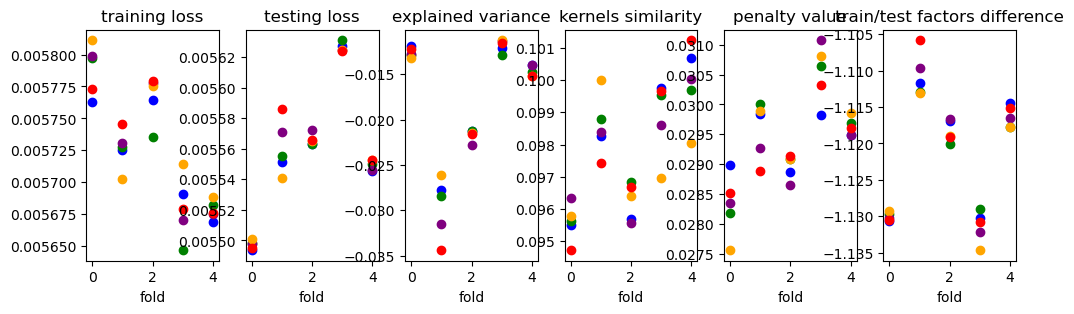

In [15]:
colors = ['blue','green','purple','orange','red']
fig, ax = plt.subplots(1,len(metric_names),figsize=(12,3))
for m in range(len(metric_names)):
    for i in range(results_learning.shape[0]):
        ax[m].scatter(torch.arange(results_learning.shape[1]),results_learning[i,:,m],color=colors[i])
    ax[m].set_title(metric_names[m])
    ax[m].set_xlabel('fold')

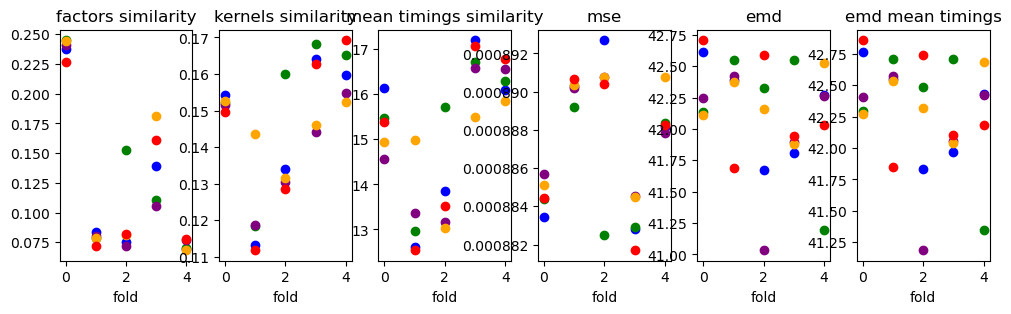

In [16]:
colors = ['blue','green','purple','orange','red']
fig, ax = plt.subplots(1,len(synthetic_metrics),figsize=(12,3))
for m in range(len(synthetic_metrics)):
    for i in range(results_learning.shape[0]):
        ax[m].scatter(torch.arange(results_learning.shape[1]),results_learning[i,:,len(metric_names)+m],color=colors[i])
    ax[m].set_title(synthetic_metrics[m])
    ax[m].set_xlabel('fold')